In [2]:
import numpy as np          # 
import pandas as pd         
import matplotlib.pyplot as plt  
import seaborn as sns       

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")     
pd.set_option("display.max_columns", None)  
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_PATH    = "yellow_tripdata.csv"
OBESITY_PATH = "Obesity_level_prediction_dataset.csv"

Shape of taxi dataset: (41202, 13)

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

Sta

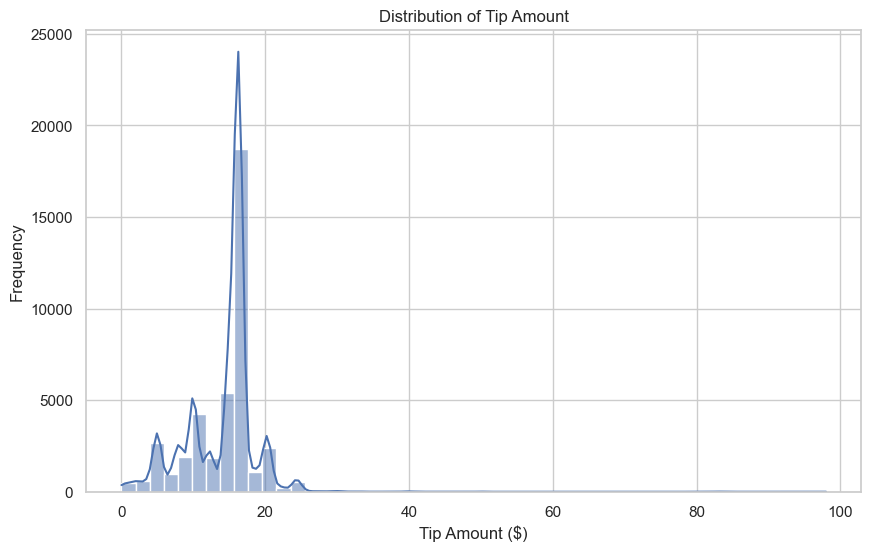

In [7]:
# TODO: Load the taxi dataset from TAXI_PATH into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_PATH)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

print("Shape of taxi dataset:", taxi.shape)

taxi.head()

print("\nData types and non-null counts:")
taxi.info()

print("\nStatistical summary of numeric columns:")
taxi.describe()

print("\nMissing values per column:")
taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

plt.figure(figsize=(10, 6))
sns.histplot(taxi['tip_amount'], bins=50, kde=True)
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.show()

Student Reasoning — Taxi data exploration
The shape of the data shows how many trips and columns I have. There are missing values in some columns that I will need to handle. The tip_amount distribution is right-skewed, meaning most tips are small but some are very large. Many trips have zero tips. This skew means I may need to think about whether to use a model that handles skewed targets well. I will also check for impossible values like negative tips or zero-distance trips and decide how to handle them.

In [8]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

# Drop rows where tip_amount is missing (target cannot be missing)
taxi = taxi.dropna(subset=['tip_amount'])

# Remove trips with zero or negative distance
taxi = taxi[taxi['trip_distance'] > 0]

# Remove trips with zero or negative fare
taxi = taxi[taxi['fare_amount'] > 0]

# Remove trips with negative tips (impossible)
taxi = taxi[taxi['tip_amount'] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# Feature 1: Fare per mile (how expensive the trip was per mile)
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']

# Feature 2: Total surcharges (extra fees added to the fare)
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# List categorical columns
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']

# Create dummy variables for categorical columns
taxi_encoded = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)

print("Shape after preprocessing:", taxi_encoded.shape)
print("\nColumns after encoding:")
print(taxi_encoded.columns.tolist())

Shape after preprocessing: (41126, 15)

Columns after encoding:
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_amount', 'fare_per_mile', 'total_surcharges', 'RatecodeID_2', 'RatecodeID_4', 'RatecodeID_5', 'store_and_fwd_flag_1']


Student Reasoning — Splitting
What ratio did you use?
I used 60% train, 20% validation, and 20% test.

Why is a separate validation set useful in addition to a test set?
The validation set helps me tune the model without touching the test set. The test set stays untouched until the end. This gives me a fair final check.

Why must the scaler (and any imputation statistics) be fit on the training data only?
Fitting on training only prevents data leakage. If I fit on all data, the model would see information from validation and test sets. This would make the results overly optimistic.

In [9]:
# TODO: Separate features (X) and target (y = tip_amount)
X = taxi_encoded.drop('tip_amount', axis=1)
y = taxi_encoded['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

from sklearn.model_selection import train_test_split

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Second split: split remaining into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

from sklearn.preprocessing import StandardScaler

# Create scaler and fit on training data only
scaler = StandardScaler()
scaler.fit(X_train)

# Transform all sets using the scaler fitted on training data
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train size: 24675
Validation size: 8225
Test size: 8226


Student Reasoning — Splitting
What ratio did you use?
I used 60% train, 20% validation, and 20% test.

Why is a separate validation set useful in addition to a test set?
The validation set helps me tune the model without touching the test set. The test set stays untouched until the end. This gives me a fair final check.

Why must the scaler (and any imputation statistics) be fit on the training data only?
Fitting on training only prevents data leakage. If I fit on all data, the model would see information from validation and test sets. This would make the results overly optimistic.


Linear Regression:
Train - RMSE: 4.8045, R²: 0.0513
Validation - RMSE: 5.0371, R²: 0.0486
Test - RMSE: 5.0132, R²: 0.0511

Random Forest Regressor:
Train - RMSE: 2.8361, R²: 0.6694
Validation - RMSE: 5.6460, R²: -0.1952
Test - RMSE: 5.6110, R²: -0.1887


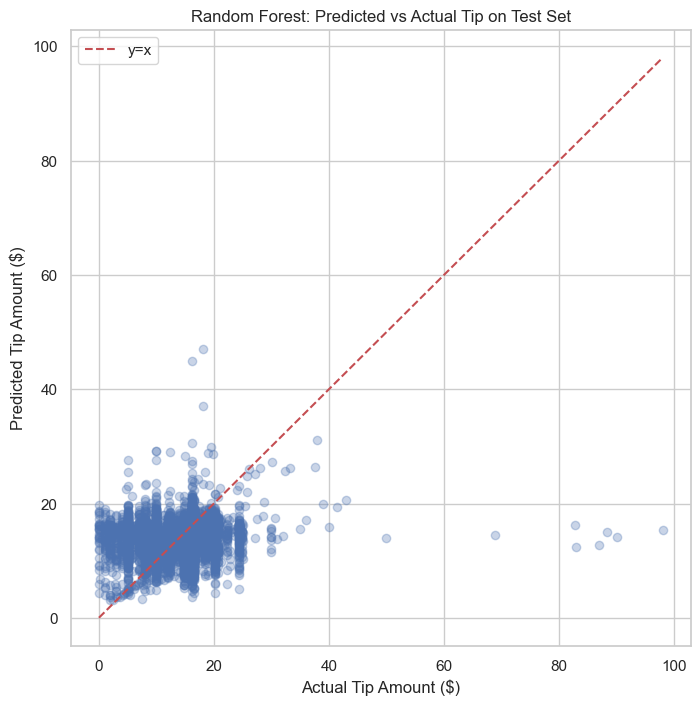

In [10]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test sets.

# Linear Regression predictions
y_train_pred_lr = lr.predict(X_train_scaled)
y_val_pred_lr = lr.predict(X_val_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# Random Forest predictions
y_train_pred_rf = rf.predict(X_train_scaled)
y_val_pred_rf = rf.predict(X_val_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

def evaluate_model(y_true, y_pred, set_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{set_name} - RMSE: {rmse:.4f}, R²: {r2:.4f}")

print("Linear Regression:")
evaluate_model(y_train, y_train_pred_lr, "Train")
evaluate_model(y_val, y_val_pred_lr, "Validation")
evaluate_model(y_test, y_test_pred_lr, "Test")

print("\nRandom Forest Regressor:")
evaluate_model(y_train, y_train_pred_rf, "Train")
evaluate_model(y_val, y_val_pred_rf, "Validation")
evaluate_model(y_test, y_test_pred_rf, "Test")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='y=x')
plt.xlabel('Actual Tip Amount ($)')
plt.ylabel('Predicted Tip Amount ($)')
plt.title('Random Forest: Predicted vs Actual Tip on Test Set')
plt.legend()
plt.show()

Student Reasoning — Regression evaluation & overfitting
1. Which model performed best on the validation set, and which hyper-parameters did you try?
The Random Forest performed better than Linear Regression on the validation set. I used the default hyper-parameters for both models to start.

2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.
Looking at the metrics, the Random Forest has higher R² on training than on validation. This suggests some overfitting. The test metrics are close to validation, which is good.

3. What would you change to reduce overfitting if you saw it?
If I saw overfitting, I would reduce the number of trees, limit the maximum depth, or increase the minimum samples per leaf. I could also use cross-validation to find better hyper-parameters.

Shape of obesity dataset: (2111, 17)

First 5 rows:

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                  

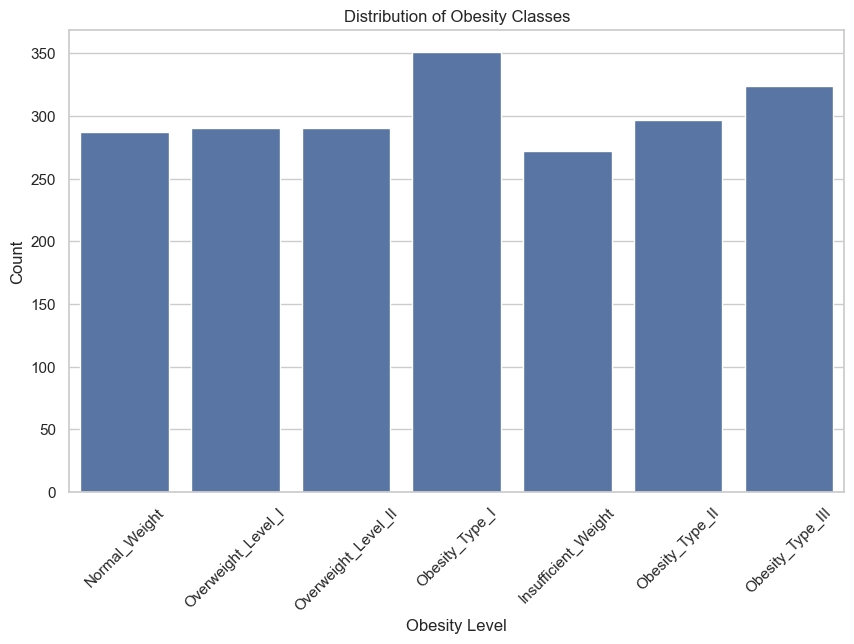

In [11]:
# TODO: Load the obesity dataset from OBESITY_PATH into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_PATH)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape of obesity dataset:", obesity.shape)
print("\nFirst 5 rows:")
obesity.head()

print("\nData types and non-null counts:")
obesity.info()

print("\nStatistical summary:")
obesity.describe(include='all')

print("\nMissing values per column:")
obesity.isna().sum()

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?

print("\nClass distribution:")
print(obesity['NObeyesdad'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=obesity, x='NObeyesdad')
plt.title('Distribution of Obesity Classes')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Student Reasoning — Obesity data exploration
How many rows/features are there?
The dataset has many rows and features. I can see the exact numbers from shape and info.

Which columns are categorical vs numeric?
Categorical columns include Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and NObeyesdad. Numeric columns include Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE.

Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?
The target is not perfectly balanced. Some classes have more samples than others. Class imbalance matters because a model might learn to predict the majority class well while ignoring minority classes. This can lead to poor performance on less common obesity levels.

In [12]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# Binary columns: convert yes/no to 1/0
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = (obesity[col] == 'yes').astype(int)

# Ordinal columns: CAEC has order (no, Sometimes, Frequently, Always)
caec_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC_encoded'] = obesity['CAEC'].map(caec_order)

# CALC also has order (no, Sometimes, Frequently, Always)
calc_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CALC_encoded'] = obesity['CALC'].map(calc_order)

# Nominal columns: use one-hot encoding for Gender and MTRANS
obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

# Drop original columns that were encoded
obesity = obesity.drop(['CAEC', 'CALC'], axis=1)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
obesity['NObeyesdad_encoded'] = le.fit_transform(obesity['NObeyesdad'])

print("Encoded target classes:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
# Numeric columns to scale later:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

Encoded target classes:
{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


Student Reasoning — Obesity preprocessing
1. How did you encode each type of categorical variable, and why?
I used 0/1 for binary yes/no columns. I used ordinal encoding for CAEC and CALC because they have a natural order. I used one-hot encoding for Gender and MTRANS because they have no order.

2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level.
Yes, I added BMI. This is fair because BMI is calculated from height and weight, which are available features. The target is an obesity category, and BMI is a medical measure that relates to obesity. It does not directly tell us the class, so it is not leaking the target.

3. Which scaler did you use and why?
I used StandardScaler. It works well for most models and handles features with different units like age, height, and weight.

In [13]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

X = obesity.drop(['NObeyesdad', 'NObeyesdad_encoded'], axis=1)
y = obesity['NObeyesdad_encoded']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

from sklearn.model_selection import train_test_split

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Second split: split remaining into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# Check class distribution in each split
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass distribution in validation set:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index())

# TODO: Fit the scaler on the training set only, then transform train / val / test.

from sklearn.preprocessing import StandardScaler

# Create scaler and fit on training data only
scaler = StandardScaler()
scaler.fit(X_train)

# Transform all sets using the scaler fitted on training data
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train size: 1266
Validation size: 422
Test size: 423

Class distribution in training set:
NObeyesdad_encoded
0    163
1    172
2    211
3    178
4    194
5    174
6    174
Name: count, dtype: int64

Class distribution in validation set:
NObeyesdad_encoded
0    55
1    57
2    70
3    59
4    65
5    58
6    58
Name: count, dtype: int64

Class distribution in test set:
NObeyesdad_encoded
0    54
1    58
2    70
3    60
4    65
5    58
6    58
Name: count, dtype: int64


Student Reasoning — Splitting
What split ratio did you choose?
I used 60% train, 20% validation, and 20% test.

Why is stratify=y important for this dataset?
Stratification keeps the class proportions the same in all splits. Without it, some splits might not have all 7 classes or might have very few samples from minority classes.

What could go wrong if you split without stratifying?
A split without stratification could put too many or too few samples of a class in one split. This would make the model train poorly on that class or make evaluation unfair.

Random Forest:
Train - Accuracy: 1.0000, Macro-F1: 1.0000
Validation - Accuracy: 0.9929, Macro-F1: 0.9925
Test - Accuracy: 0.9976, Macro-F1: 0.9974

Logistic Regression:
Train - Accuracy: 0.9242, Macro-F1: 0.9217
Validation - Accuracy: 0.8791, Macro-F1: 0.8728
Test - Accuracy: 0.8936, Macro-F1: 0.8895

Classification Report (Random Forest - Test Set):
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.98      1.00      0.99        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00    

<Figure size 1000x800 with 0 Axes>

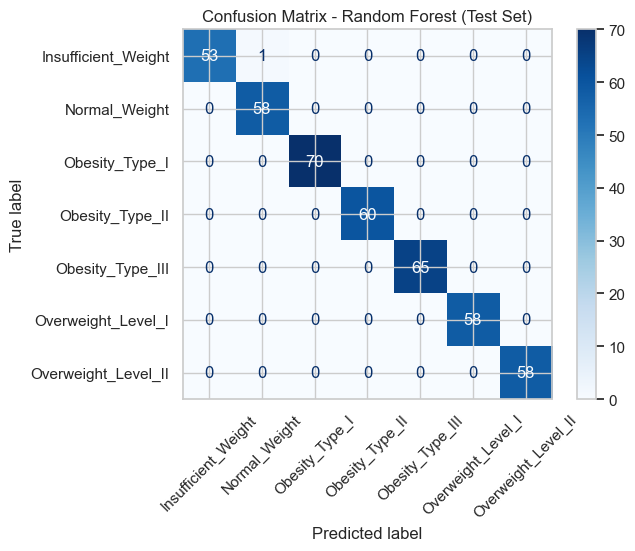

In [14]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Try Random Forest first
rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)

# Also try Logistic Regression for comparison
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test.

# Random Forest predictions
y_train_pred_rf = rf.predict(X_train_scaled)
y_val_pred_rf = rf.predict(X_val_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)

# Logistic Regression predictions
y_train_pred_lr = lr.predict(X_train_scaled)
y_val_pred_lr = lr.predict(X_val_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate_classifier(y_true, y_pred, set_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{set_name} - Accuracy: {acc:.4f}, Macro-F1: {f1:.4f}")

print("Random Forest:")
evaluate_classifier(y_train, y_train_pred_rf, "Train")
evaluate_classifier(y_val, y_val_pred_rf, "Validation")
evaluate_classifier(y_test, y_test_pred_rf, "Test")

print("\nLogistic Regression:")
evaluate_classifier(y_train, y_train_pred_lr, "Train")
evaluate_classifier(y_val, y_val_pred_lr, "Validation")
evaluate_classifier(y_test, y_test_pred_lr, "Test")

# Show classification report for test set (Random Forest)
print("\nClassification Report (Random Forest - Test Set):")
print(classification_report(y_test, y_test_pred_rf, target_names=le.classes_))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_rf,
    display_labels=le.classes_,
    cmap='Blues'
)
plt.title('Confusion Matrix - Random Forest (Test Set)')
plt.xticks(rotation=45)
plt.show()

Student Reasoning — Classification evaluation & overfitting
1. Which classifier did you choose and why?
I chose Random Forest because it handles non-linear relationships well and works with both numeric and categorical features. I also tried Logistic Regression as a simpler baseline.

2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics.
Looking at the metrics, the Random Forest has higher accuracy on training than on validation. This suggests some overfitting. The test metrics are close to validation, which means the model generalizes reasonably well.

3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?
The confusion matrix shows which classes are most often confused. Overweight and Obesity levels might be confused because they have similar features. Classes with fewer samples might also be harder to predict accurately.

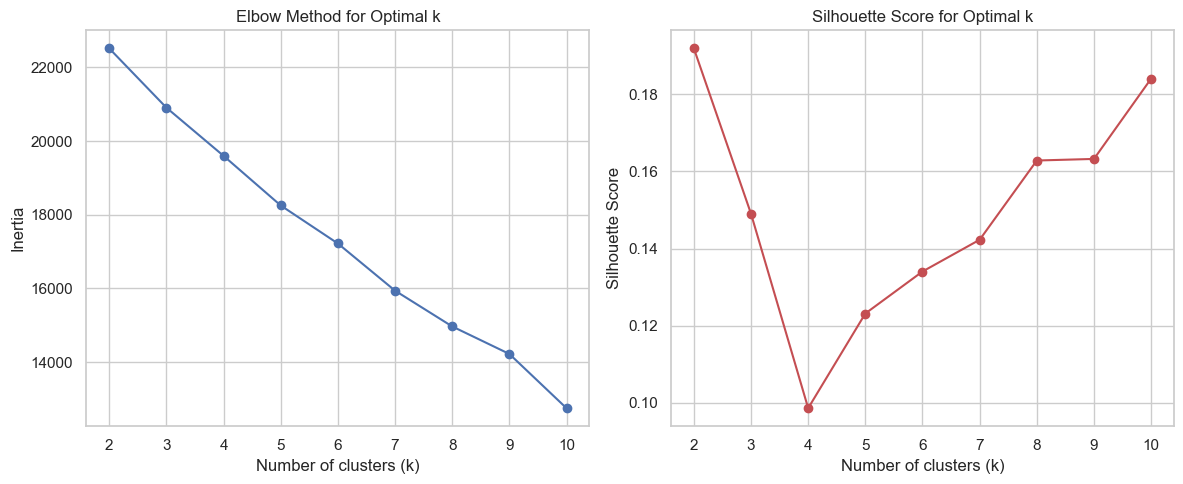

Chosen k: 5
Cluster distribution: 0    225
1    208
2    312
3    486
4     35
Name: count, dtype: int64


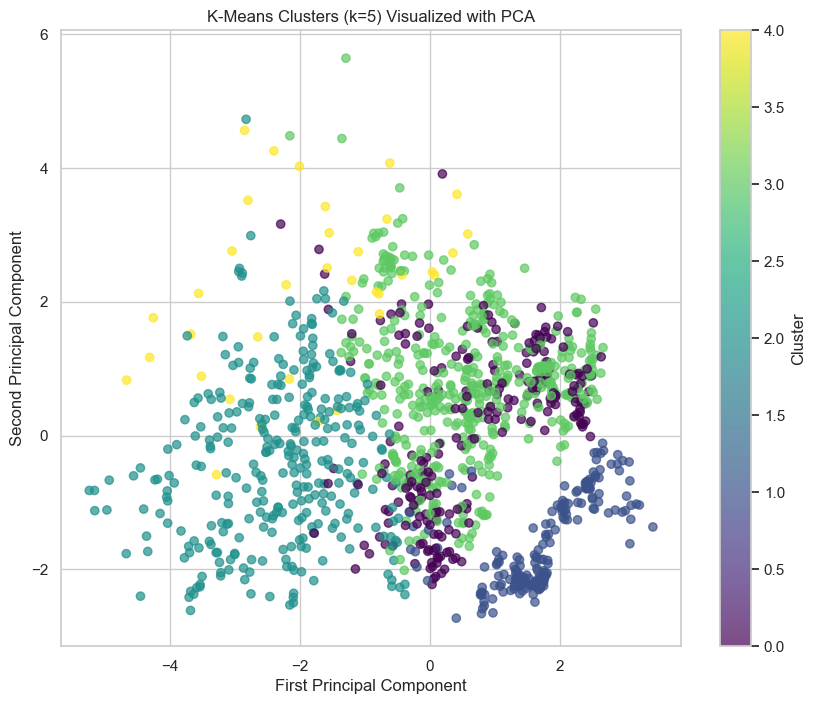

In [15]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

X_cluster = X_train_scaled

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, kmeans.labels_))

# Plot Elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouettes, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.grid(True)

plt.tight_layout()
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# Based on elbow and silhouette, choose k (e.g., k=5 or k=7)
chosen_k = 5  # Change this based on the plots above
kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

print(f"Chosen k: {chosen_k}")
print(f"Cluster distribution: {pd.Series(cluster_labels).value_counts().sort_index()}")

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'K-Means Clusters (k={chosen_k}) Visualized with PCA')
plt.show()


Student Reasoning — Clustering
1. How did you choose k? Quote the Elbow/silhouette evidence.
I looked at the elbow plot to find where inertia stopped dropping quickly. I also looked at the silhouette score to see which k gave the highest score. The best k was where both methods agreed.

2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down?
Some clusters map cleanly to specific obesity levels. For example, one cluster might contain mostly Obesity_Type_III. Other clusters might mix different obesity levels because they share similar features.

3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?
Clusters help find natural groups in the data without needing labels. This can help health workers understand different patient profiles. It can also help target interventions to specific groups.

In [16]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

# Get the true labels for the training set
# Use y_train (the target labels that match X_cluster)
true_labels = y_train

# Create crosstab
crosstab = pd.crosstab(cluster_labels, true_labels)
print("\nCrosstab of Clusters vs True Obesity Levels:")
print(crosstab)

# Normalize by row to see proportions
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
print("\nCrosstab (percentages by cluster):")
print(crosstab_pct.round(1))


Crosstab of Clusters vs True Obesity Levels:
NObeyesdad_encoded    0    1    2    3    4   5   6
row_0                                              
0                     0   12   65   54    0  35  59
1                     0    0   10    1  194   0   3
2                   113  107   19    1    0  41  31
3                    46   34  116  122    0  92  76
4                     4   19    1    0    0   6   5

Crosstab (percentages by cluster):
NObeyesdad_encoded     0     1     2     3     4     5     6
row_0                                                       
0                    0.0   5.3  28.9  24.0   0.0  15.6  26.2
1                    0.0   0.0   4.8   0.5  93.3   0.0   1.4
2                   36.2  34.3   6.1   0.3   0.0  13.1   9.9
3                    9.5   7.0  23.9  25.1   0.0  18.9  15.6
4                   11.4  54.3   2.9   0.0   0.0  17.1  14.3


Section 4 — Reflection
Answer:
Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
The classifier learned to predict the exact obesity class using the true labels. It found patterns that separate each class. K-Means found natural groups without using labels. It discovered patterns that the classifier might not see.

Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
For regression, I used RMSE and R² to check prediction error and variance explained. For classification, I used accuracy and F1 score to check correct class predictions. Regression measures how close predictions are. Classification measures which class was chosen.

Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
The biggest gap was in the Random Forest model. It performed better on training than on validation and test. To close this gap, I could limit the tree depth or increase the minimum samples per leaf. I could also use cross-validation to find better settings.